In [9]:
import sys
!{sys.executable} -m pip install cupy-cuda12x

In [10]:
# CPU
import cupy as cp
import numpy as np
import time
import matplotlib.pyplot as plt

In [11]:
def matmul_cpu(A, B):
    start = time.time()
    C = np.dot(A, B)
    end = time.time()
    return C, end - start

In [12]:
def matmul_gpu(A, B):
    # Конвертируем в float32
    A = A.astype(np.float32)
    B = B.astype(np.float32)
    
    # Перенос на GPU
    A_device = cp.asarray(A)
    B_device = cp.asarray(B)
    
    # Синхронизация для точного замера времени
    cp.cuda.Stream.null.synchronize()
    start = time.time()
    
    # Перемножение матриц
    C_device = cp.dot(A_device, B_device)
    
    # Синхронизация после вычислений
    cp.cuda.Stream.null.synchronize()
    end = time.time()
    
    # Возвращение результате на CPU
    C = cp.asnumpy(C_device)
    
    return C, end - start

In [13]:
def gen_matr(n):
    return np.random.rand(n, n).astype(np.float32)


def correct(C_cpu, C_gpu, eps=1e-3):
    return np.allclose(C_cpu, C_gpu, atol=eps)

--------------------------------------------------
Matrix Size    CPU (sec)      GPU (sec)      Speedup        
--------------------------------------------------
100            0.000460       0.000246       1.87           
200            0.015304       0.000139       110.29         
300            0.016438       0.000140       117.46         
400            0.024647       0.000170       144.78         
500            0.026162       0.000180       145.53         
600            0.024488       0.000201       121.98         
700            0.020486       0.000213       96.33          
800            0.020000       0.000240       83.30          
900            0.020593       0.000271       75.96          
1000           0.005595       0.000304       18.39          
1100           0.006297       0.000354       17.78          
1200           0.009918       0.000401       24.73          
1300           0.009746       0.000463       21.04          
1400           0.012506       0.000487      

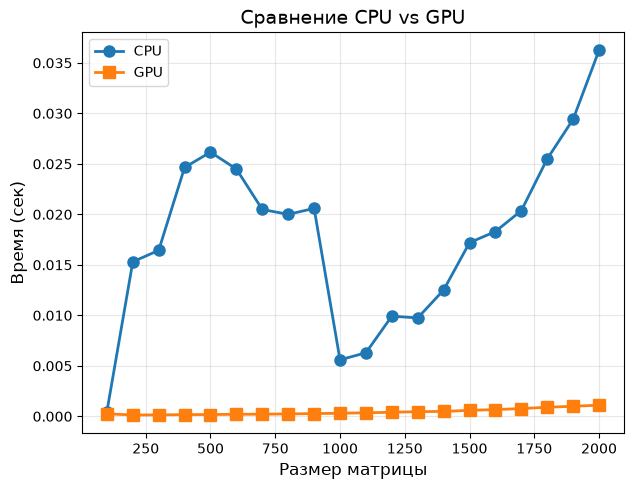

In [14]:
sizes = list(range(100, 2001, 100))

cpu_times = []
gpu_times = []
speedups = []

print("-" * 50)
print(f"{'Matrix Size':<15}{'CPU (sec)':<15}{'GPU (sec)':<15}{'Speedup':<15}")
print("-" * 50)

for n in sizes:
    A = gen_matr(n)
    B = gen_matr(n)

    C_cpu, t_cpu = matmul_cpu(A, B)
    C_gpu, t_gpu = matmul_gpu(A, B)

    correct_check = correct(C_cpu, C_gpu)
    
    # Вычисление ускорения
    speedup = t_cpu / t_gpu if t_gpu > 0 else 0

    cpu_times.append(t_cpu)
    gpu_times.append(t_gpu)
    speedups.append(speedup)

    print(f"{n:<15}{t_cpu:<15.6f}{t_gpu:<15.6f}{speedup:<15.2f}")

print("-" * 50)

# Вывод среднего ускорения
avg_speedup = sum(speedups) / len(speedups)
print(f"\nСреднее ускорение: {avg_speedup:.2f}x")
print(f"Максимальное ускорение: {max(speedups):.2f}x")
print(f"Минимальное ускорение: {min(speedups):.2f}x")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(sizes, cpu_times, marker='o', label='CPU', linewidth=2, markersize=8)
plt.plot(sizes, gpu_times, marker='s', label='GPU', linewidth=2, markersize=8)
plt.xlabel("Размер матрицы", fontsize=12)
plt.ylabel("Время (сек)", fontsize=12)
plt.title("Сравнение CPU vs GPU", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("cpu_vs_gpu.png", dpi=300, bbox_inches='tight')
plt.show()